In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold1_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold2_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold2_05["fold"] = [2 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [5]:
df = pd.concat([fold0_05, fold1_05, fold2_05], ignore_index=True)

In [6]:
len(df)

164

In [7]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [8]:
df['optimization_successful'] = df['URQ_delta'] < -0.05

In [9]:
successful_df = df[df['optimization_successful'] == True]

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

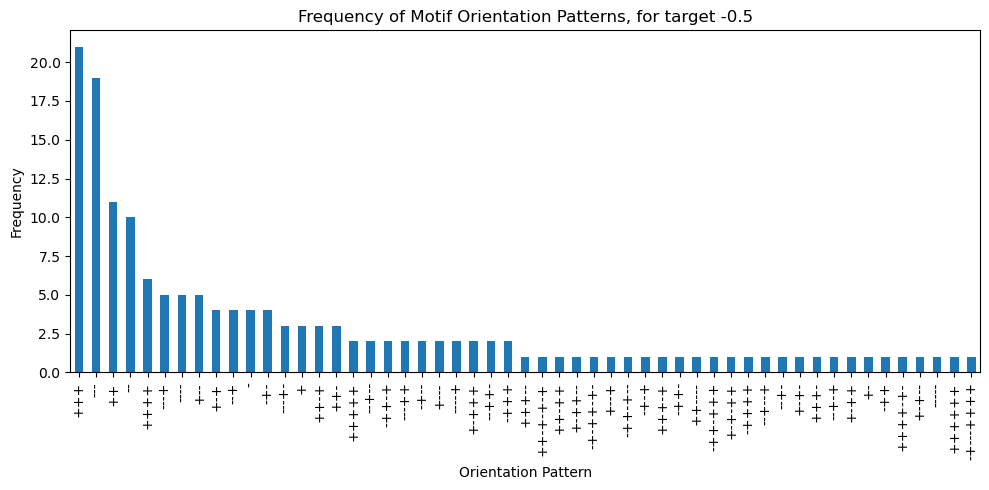

In [11]:
orientation_counts = successful_df[successful_df['orientation'] != "no"]['orientation'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target -0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
df_melted = successful_df.melt(value_vars=['URQ_result', 'URQ_target'], var_name='Type', value_name='URQ mean')

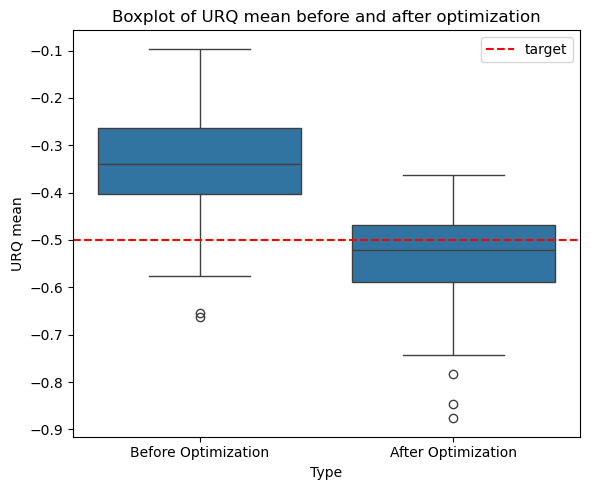

In [13]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Type', y='URQ mean', data=df_melted)
plt.axhline(y=-0.5, color='red', linestyle='--', linewidth=1.5, label='target')
plt.xticks([0, 1], ['Before Optimization', 'After Optimization'])
plt.title('Boxplot of URQ mean before and after optimization')
plt.legend()
plt.tight_layout()
plt.show()

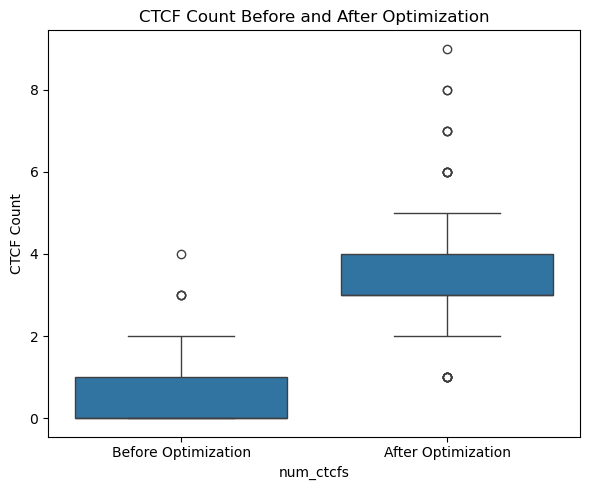

In [14]:
df_box_melted = successful_df.melt(value_vars=['init_CTCFs_num', 'CTCFs_num'],
                            var_name='num_ctcfs', value_name='CTCF Count')

# Rename the categories for clarity
label_map = {
    'init_CTCFs_num': 'Before Optimization',
    'CTCFs_num': 'After Optimization'
}
df_box_melted['num_ctcfs'] = df_box_melted['num_ctcfs'].map(label_map)

# Plotting
plt.figure(figsize=(6, 5))
sns.boxplot(x='num_ctcfs', y='CTCF Count', data=df_box_melted)
plt.title('CTCF Count Before and After Optimization')
plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import pearsonr

In [16]:
# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(successful_df['URQ_target'], successful_df['URQ_result'])

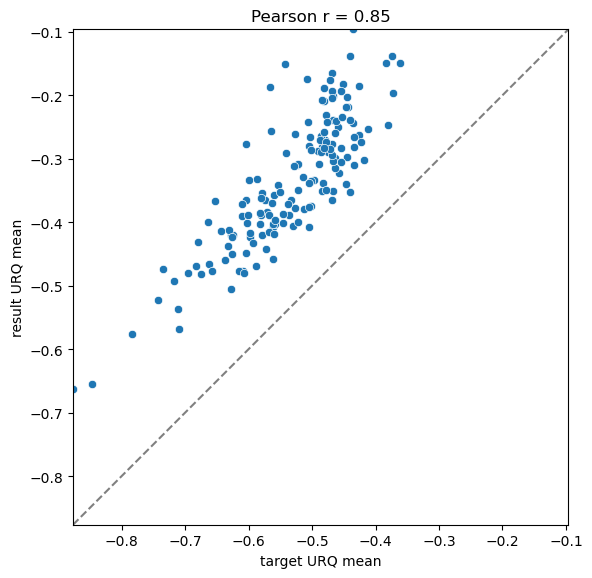

In [17]:
# Determine shared range for both axes
min_val = min(successful_df['URQ_target'].min(), successful_df['URQ_result'].min())
max_val = max(successful_df['URQ_target'].max(), successful_df['URQ_result'].max())

# Plotting the scatterplot with equal axis limits and square aspect ratio
plt.figure(figsize=(6, 6))
sns.scatterplot(x='URQ_target', y='URQ_result', data=successful_df)
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')  # reference diagonal
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f'Pearson r = {r_value:.2f}')
plt.xlabel('target URQ mean')
plt.ylabel('result URQ mean')
plt.tight_layout()
plt.show()


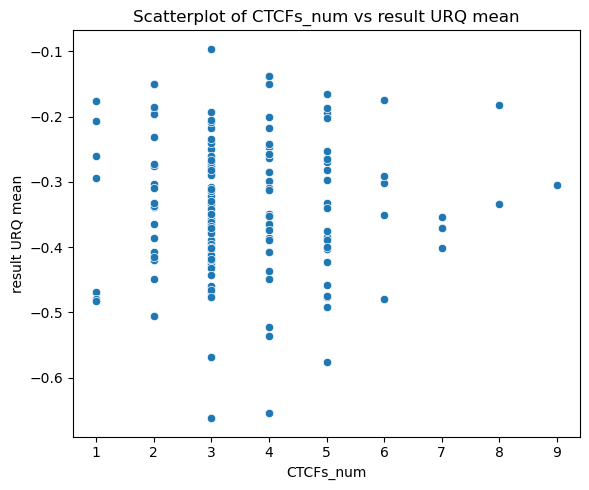

In [18]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='URQ_result', data=successful_df)
plt.xlabel('CTCFs_num')
plt.ylabel('result URQ mean')
plt.title('Scatterplot of CTCFs_num vs result URQ mean')
plt.tight_layout()
plt.show()

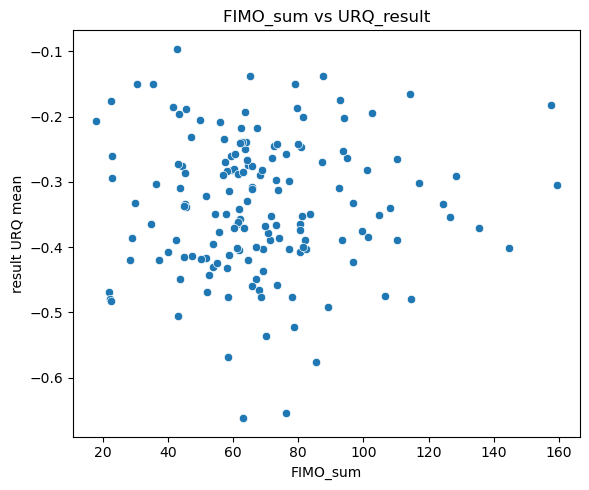

In [19]:
# Plotting the scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='URQ_result', data=successful_df)
plt.xlabel('FIMO_sum')
plt.ylabel('result URQ mean')
plt.title(f'FIMO_sum vs URQ_result')
plt.tight_layout()
plt.show()

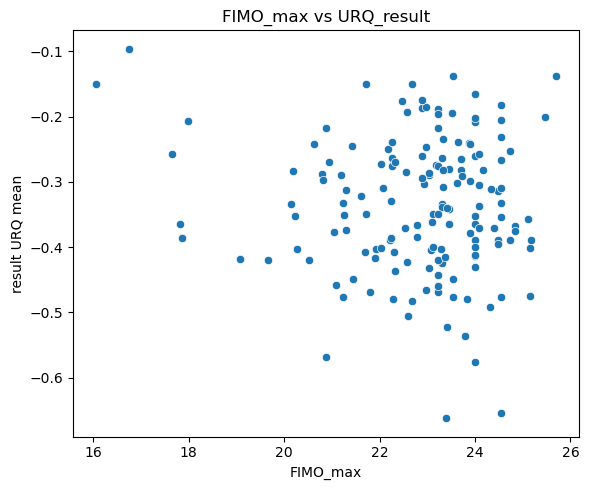

In [20]:
# Plotting the scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='URQ_result', data=successful_df)
plt.xlabel('FIMO_max')
plt.ylabel('result URQ mean')
plt.title(f'FIMO_max vs URQ_result')
plt.tight_layout()
plt.show()

/tmp/SLURM_1378779/ipykernel_2361267/1108996573.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


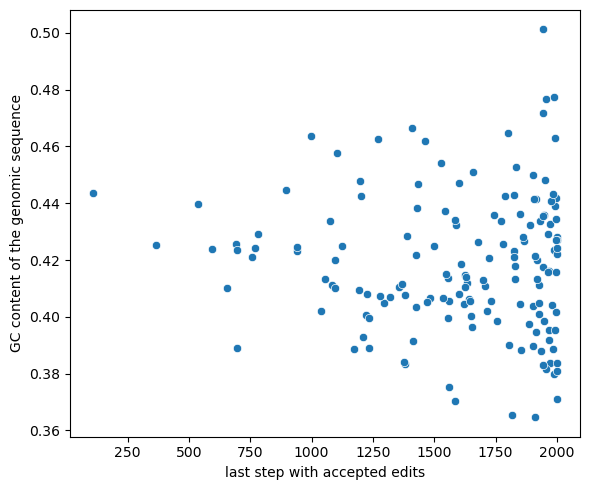

In [21]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step',
    y='GC_seq',
    data=successful_df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

/tmp/SLURM_1378779/ipykernel_2361267/1625390447.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


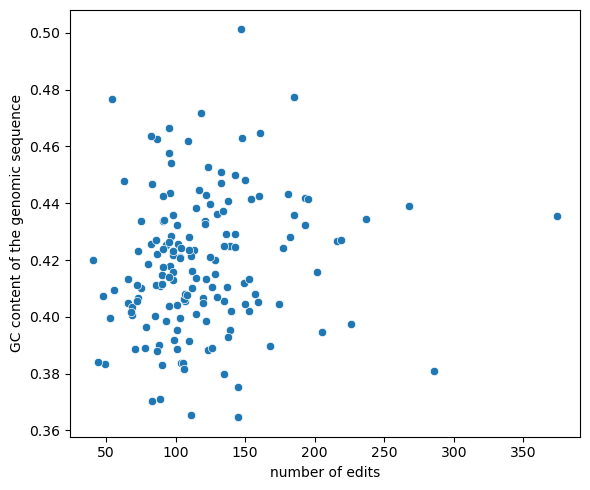

In [22]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='GC_seq',
    data=successful_df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

/tmp/SLURM_1378779/ipykernel_2361267/2333646849.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


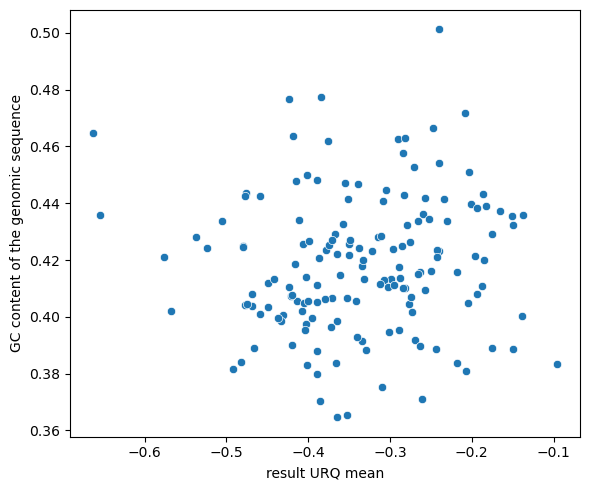

In [23]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='URQ_result',
    y='GC_seq',
    data=successful_df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('result URQ mean')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

/tmp/SLURM_1378779/ipykernel_2361267/2275746319.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


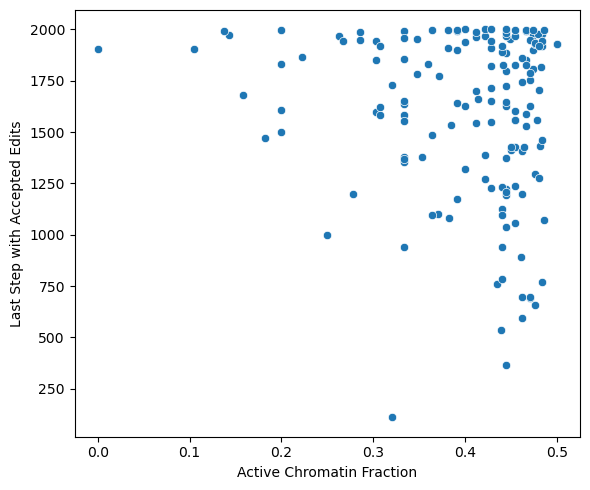

In [24]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='last_accepted_step',
    data=successful_df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()


/tmp/SLURM_1378779/ipykernel_2361267/2729228781.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


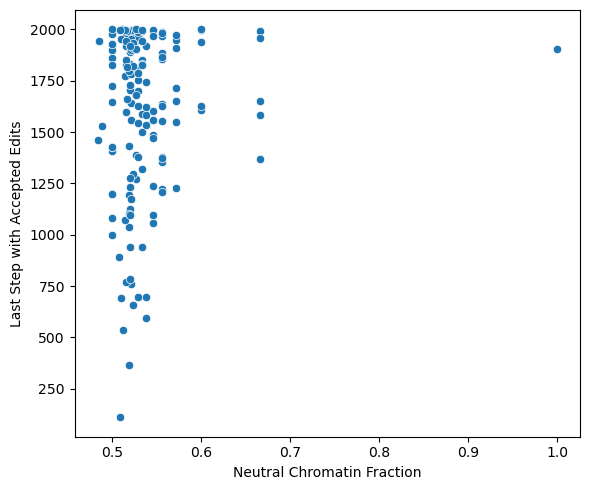

In [25]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='last_accepted_step',
    data=successful_df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

/tmp/SLURM_1378779/ipykernel_2361267/802640570.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


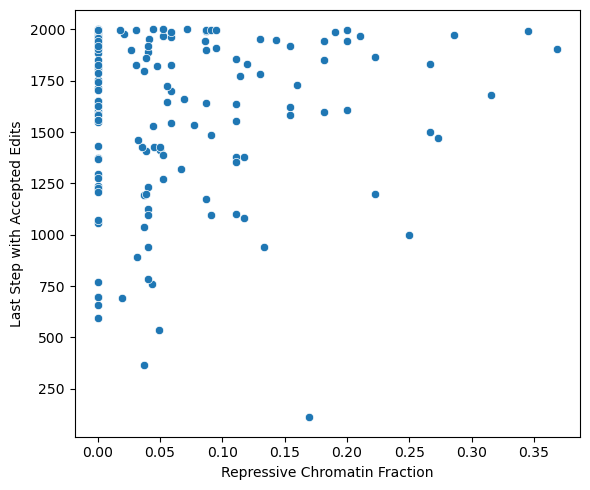

In [26]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='last_accepted_step',
    data=successful_df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

/tmp/SLURM_1378779/ipykernel_2361267/299067056.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


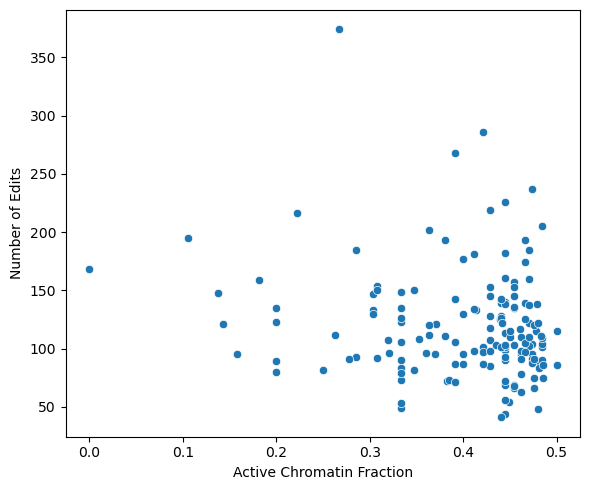

In [27]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='num_edits',
    data=successful_df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Number of Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

/tmp/SLURM_1378779/ipykernel_2361267/3245597440.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


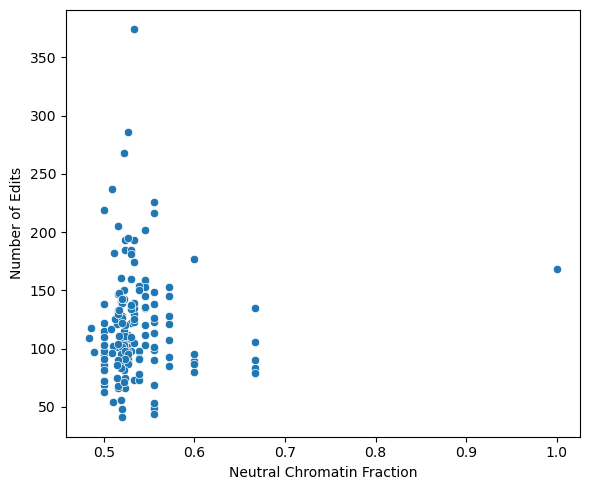

In [28]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='num_edits',
    data=successful_df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Number of Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

/tmp/SLURM_1378779/ipykernel_2361267/1632987003.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


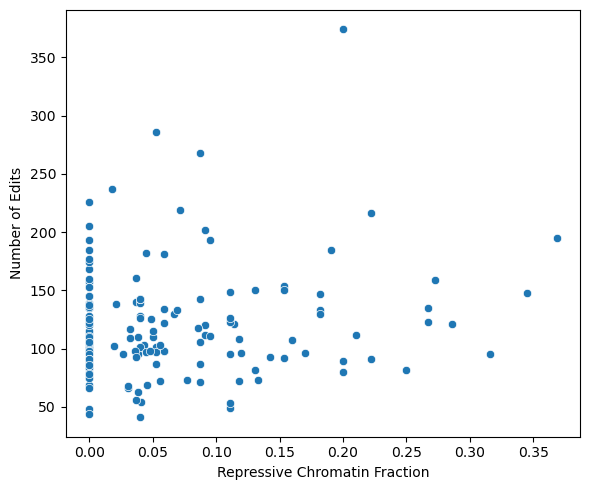

In [29]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='num_edits',
    data=successful_df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Number of Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

/tmp/SLURM_1378779/ipykernel_2361267/1236298076.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  successful_df['set'] = successful_df['fold'].map(fold_map)


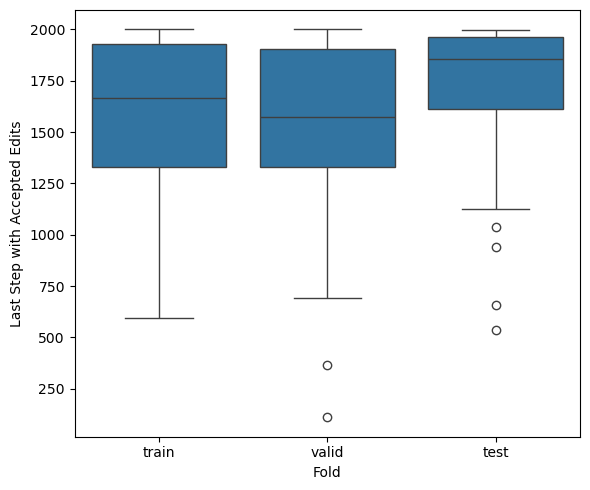

In [30]:
fold_map = {0: 'test', 1: 'valid', 2: 'train'}
successful_df['set'] = successful_df['fold'].map(fold_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='last_accepted_step', data=successful_df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Last Step with Accepted Edits')
plt.tight_layout()
plt.show()

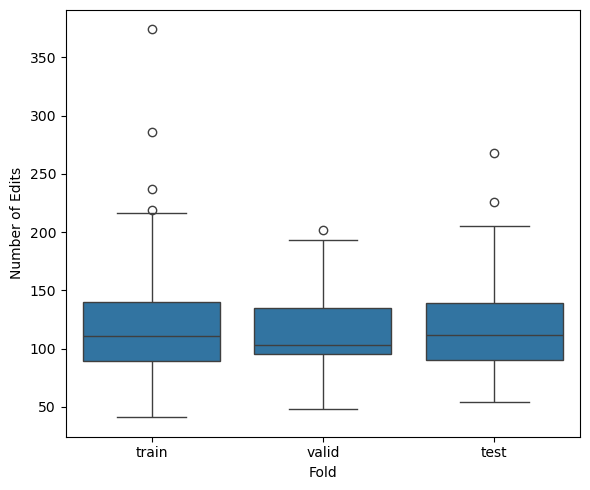

In [31]:
# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='num_edits', data=successful_df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Number of Edits')
plt.tight_layout()
plt.show()

In [32]:
from scipy.stats import ttest_rel

In [34]:
t_stat, p_val = ttest_rel(successful_df['GC_slice'], successful_df['GC_slice_edited'])

In [35]:
t_stat, p_val

(-13.443711551422918, 7.4621102904884655e-28)

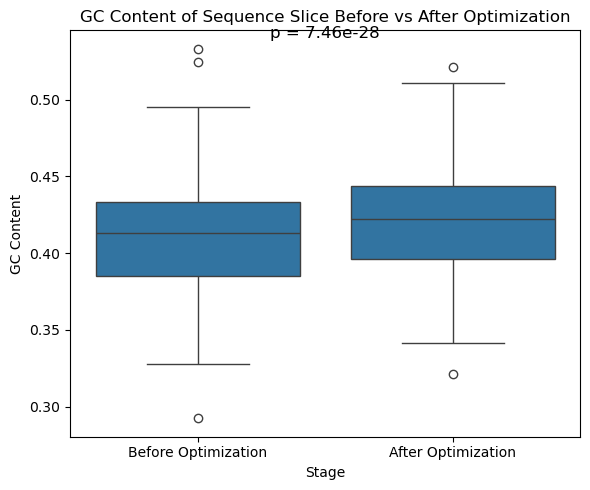

In [37]:
# Melt the DataFrame for plotting
df_gc_melted = successful_df.melt(value_vars=['GC_slice', 'GC_slice_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice': 'Before Optimization',
    'GC_slice_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice Before vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()